# Cài đặt các Thư viện sử dụng

In [46]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import os
import joblib
import seaborn as sns
import random
import numpy as np

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

In [48]:
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

from gensim.models import Word2Vec

from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

In [50]:
import warnings
warnings.filterwarnings("ignore")

**Cài đặt hiển thị dataFrame**

In [51]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

**Đọc dữ liệu**

In [52]:

file = os.path.join("../../Data_Train", "Vietnamese.csv")
data_df = pd.read_csv(file, encoding = 'utf-8')

file_stopword = os.path.join("../../Data_Train", "vietnamese-stopwords-dash.txt")
with open(file_stopword, 'r', encoding='utf-8') as file:
    stopwords = file.read().split('\n')

# Khám phá dữ liệu

**Xem thông tin giữ liệu**

In [53]:
data_df.head(5)

title  \
0     Cấm biển di dân khỏi vùng nguy hiểm từ Quảng Ninh đến Nghệ An   
1  Hội Cựu Công an nhân dân là thành viên Mặt trận Tổ quốc Việt Nam   
2     Thêm 30 cá thể hổ và sư tử ở Vườn thú Mỹ Quỳnh (Long An) chết   
3                        Đà Lạt: Lũ cuốn trôi ô tô 1 người mất tích   
4       Kiên Giang: Cất bốc 19 hài cốt liệt sĩ tại huyện Kiên Lương   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

**Xáo trộn dữ liệu**

In [54]:
data_df=data_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [55]:
data_df.head(5)

title  \
0                                                               Lưỡi gỗ Nguyễn Viết Thông   
1               Biển Đông: Trung Quốc âm mưu chia rẽ Việt Nam và Philippines nên đoàn kết   
2                           Mất căn cước công dân ở nước ngoài tôi có được cấp lại không?   
3                                    Đường dây dùng trẻ em phục vụ khiêu dâm bị phát hiện   
4  Phạm Minh Hoàng: Hội Thánh Truyền Giáo Phục Hưng hay lãnh đạo CSVN gây lây nhiễm dịch?   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

**Mô tả dữ liệu**

In [56]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12600 entries, 0 to 12599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   12600 non-null  object
 1   text    12600 non-null  object
 2   label   12600 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 295.4+ KB


In [57]:
data_df.describe().round(1)

,label
count,12600.0
mean,0.5
std,0.5
min,0.0
25%,0.0
50%,0.0
75%,1.0
max,1.0


**Kích thước của dataFrame và danh sách các tên cột**

In [58]:
features = data_df.columns.to_list()[:]
print(data_df.shape)
print(features)

(12600, 3)
['title', 'text', 'label']


**ý nghĩa các cột**
- title: Tên của tin tức
- text: nội dung của tin tức
- label: nhãn phân biệt tin giả hay tin thật

**Xem số hàng và cột của dữ liệu**

In [59]:
num_rows=data_df.shape[0]
num_cols=data_df.shape[1]
print(num_rows)
print(num_cols)

12600
3


**Kiểm tra dữ liệu có bị lặp**

In [60]:
dup=data_df.index.duplicated().sum()
dup

0

**Kiểm tra dữ liệu có bị thiếu**

In [61]:
data_df['title'].isnull().sum()

0

In [62]:
data_df['text'].isnull().sum()

0

In [63]:
data_df['label'].isnull().sum()

0

**Kiểm tra loại dữ liệu**

In [64]:
def open_object_dtype(s):
    dtypes = set()
    s=s.apply(type)
    dtypes.update(s.unique().tolist())
    return dtypes

In [65]:
open_object_dtype(data_df['title'])

{str}

In [66]:
open_object_dtype(data_df['text'])

{str}

In [67]:
open_object_dtype(data_df['label'])

{int}

**Kiểm tra số từ của title và text**

In [68]:
data_df["title_length"] = data_df["title"].apply(lambda title: len(title.split(" ")))
data_df["text_length"] = data_df["text"].apply(lambda text: len(text.split(" ")))

In [69]:
data_df[["title_length", "text_length"]].describe()

,title_length,text_length
count,12600.000000,12600.000000
mean,13.281905,913.570556
std,4.446797,828.093960
min,1.000000,52.000000
25%,10.000000,384.000000
50%,14.000000,699.000000
75%,16.000000,1174.000000
max,47.000000,15495.000000


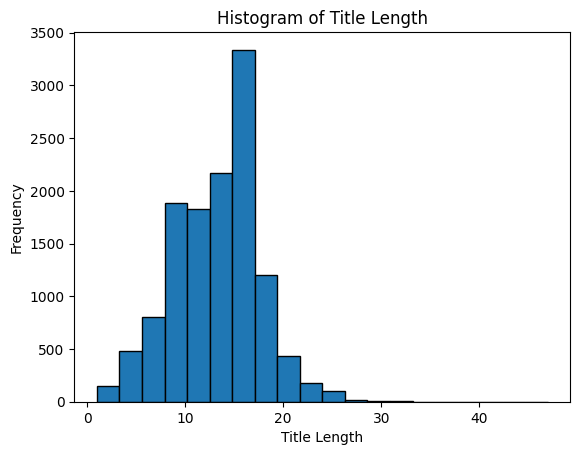

In [70]:
data_df["title_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Title Length')
plt.xlabel('Title Length')
plt.ylabel('Frequency')
plt.show()

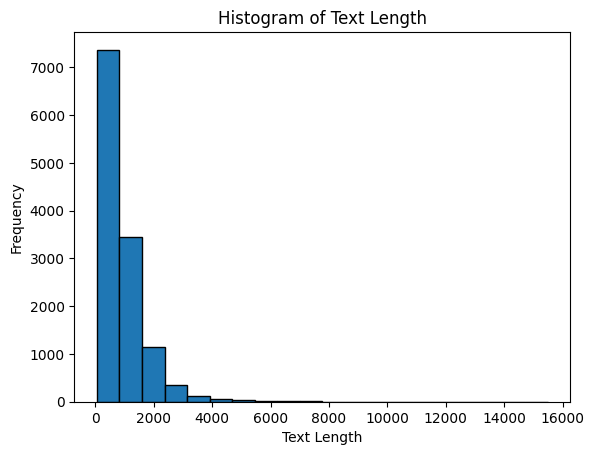

In [71]:
data_df["text_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

**Xem phân bố dữ liệu**

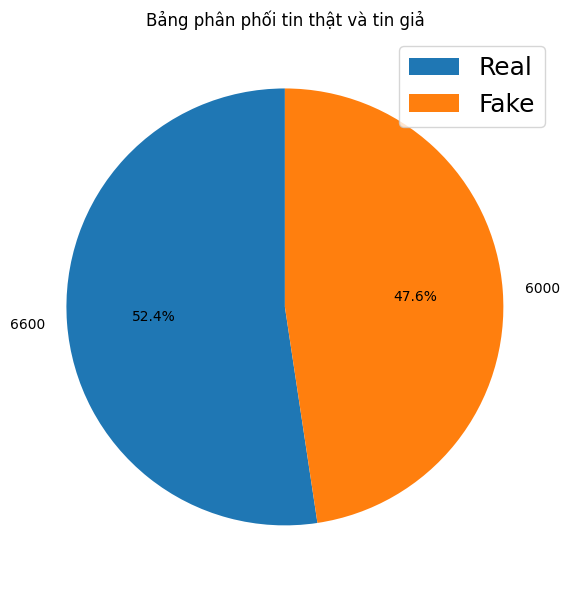

In [72]:
# data quantity chart
def quantity_chart():
    counts_df1 = data_df['label'].value_counts()

    plt.figure(figsize=(6, 6))

    plt.pie(counts_df1, labels=counts_df1, autopct='%1.1f%%', startangle=90)
    plt.title('Bảng phân phối tin thật và tin giả')

    labels = ['Real' if label == 0 else 'Fake' for label in counts_df1.index]
    plt.legend(labels=labels, loc="best", fontsize=18)  # Tăng kích thước nhãn trong chú thích
    plt.tight_layout()
    plt.show()
quantity_chart()

**Chiều dài trung bình tiêu đề của 1 tin tức**

In [73]:
len_title_sum=0

for i in data_df['title']:
    len_word=i.split()
    len_title_sum += len(len_word)

avg_title=len_title_sum/data_df['title'].count()

avg_title

13.282619047619047

**Độ dài lớn nhất của tiêu đề**

In [74]:
max_title_len=0
for i in data_df['title']:
    len_word = i.split()
    if len(len_word) > max_title_len:
        max_title_len = len(len_word)
max_title_len

47

**Độ dài nhỏ nhất của tiêu đề**

In [75]:
min_title_len=max_title_len

for i in data_df['title']:
    len_word=i.split()
    if len(len_word) < min_title_len:
        min_title_len = len(len_word)

min_title_len

1

**Chiều dài trung bình text của 1 tin tức**

In [76]:
len_text_sum=0

for i in data_df['text']:
    len_word=i.split()
    len_text_sum += len(len_word)

avg_text=len_text_sum/data_df['text'].count()

avg_text

913.5705555555555

**Độ dài lớn nhất của text**

In [77]:
max_text_len=0

for i in data_df['text']:
    len_word=i.split()
    if len(len_word)>max_text_len:
        max_text_len=len(len_word)

max_text_len

15495

**Độ dài nhỏ nhất của text**

In [78]:
min_text_len = max_text_len

for i in data_df['text']:
    len_word=i.split()
    if len(len_word) < min_text_len:
        min_text_len = len(len_word)

min_text_len

52

**Tổng số từ trong title**

In [79]:
total_words = data_df['title'].str.split().map(len).sum()
total_words

167361

**Tổng số từ trong text**

In [80]:
total_words = data_df['text'].str.split().map(len).sum()
total_words

11510989

**Số từ khác biệt trong title**

In [81]:
unique_words = len(set(' '.join(data_df['title']).split()))
unique_words

11752

**Số từ khác biệt trong text**

In [82]:
unique_words = len(set(' '.join(data_df['text']).split()))
unique_words

115253

# Tiền xử lí văn bản

#### Loại bỏ các đường link và các dấu câu, lowercase

**Thư viện để xử lý**

In [83]:
from pyvi import ViTokenizer

**Loại bỏ các đường link và các dấu câu, lowercase**

In [84]:
def wordopt(text):
    text = text.lower()
    text = re.sub('[%s]' % re.escape("""!–"#$%&'()*+,،-./:;<=>؟?@[\]^`{|}~“”…؛"""), ' ', text)
    text = re.sub('https?://\S+|www\.\S+|https?:\/\/.*[\r\n]*', ' ', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('\\W', ' ', text)
    text = re.sub('\w*\d\w*', '', text)
    text = re.sub('\n', ' ', text)
    text = re.sub('\s+', ' ', text)
    text = text.strip()

    update_text = ""
    for word in text.split():
        if word not in stopwords:
            update_text += word+" "
        
    return update_text.strip()

In [85]:
# Compound Vietnamese word
def tokenizerVN(text):
    return ViTokenizer.tokenize(text)

**Hợp nhất title và text**

In [86]:
data_df['article'] = data_df["title"] +  data_df["text"] 

In [87]:
data_df.head(1)

title  \
0  Lưỡi gỗ Nguyễn Viết Thông   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

**Áp dụng các xử lý dữ liệu**

In [88]:
data_df['Compound_Content'] = data_df['article'].apply(tokenizerVN)

In [89]:
data_df['Compound_Content_SW'] = data_df['Compound_Content'].apply(wordopt)

In [90]:
data_df.head(1)

title  \
0  Lưỡi gỗ Nguyễn Viết Thông   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

**Tổng số từ**

In [91]:
total_words = data_df['Compound_Content_SW'].str.split().map(len).sum()
total_words

4335055

**Số từ khác biệt còn lại**

In [92]:
unique_words_combined = len(set(' '.join(data_df['Compound_Content_SW']).split()))
unique_words_combined

98996

**Xác định tần suất xuất hiện các từ trong từng tài liệu**

In [93]:
from collections import Counter

In [94]:
word_counts_per_document = []

# Duyệt qua từng tài liệu
for doc in data_df['Compound_Content_SW']:
    words_in_doc = set(doc.split())  # Sử dụng set để loại bỏ từ trùng trong mỗi tài liệu
    word_counts_per_document.append(words_in_doc)

# Bước 4: Đếm tổng số lần xuất hiện của các từ trong tất cả các tài liệu (mỗi từ chỉ tính một lần trong một tài liệu)
total_word_counts = Counter()

# Duyệt qua danh sách các từ trong từng tài liệu và cập nhật tổng số đếm
for word_set in word_counts_per_document:
    total_word_counts.update(word_set)

In [95]:
print(len(total_word_counts))
for word, count in total_word_counts.most_common():
    print(f"{word}: {count/len(data_df)}")


98996
đi: 0.5246031746031746
dân: 0.5047619047619047
việt_nam: 0.5015079365079365
hai: 0.48928571428571427
tổ_chức: 0.3807936507936508
tỉnh: 0.36976190476190474
vụ: 0.36507936507936506
đầu: 0.3557936507936508
ảnh: 0.3503968253968254
đường: 0.3476984126984127
công_an: 0.34055555555555556
xã_hội: 0.3404761904761905
cơ_quan: 0.336984126984127
lãnh_đạo: 0.3319047619047619
hàng: 0.3308730158730159
đảng: 0.3281746031746032
đồng: 0.31246031746031744
viết: 0.31055555555555553
quốc_gia: 0.308015873015873
thông_tin: 0.30666666666666664
nhà_nước: 0.3007936507936508
khu_vực: 0.29825396825396827
hà_nội: 0.2966666666666667
xảy: 0.2930952380952381
hoạt_động: 0.2853174603174603
tiền: 0.28206349206349207
kinh_tế: 0.27753968253968253
chủ_tịch: 0.2734920634920635
chính_trị: 0.2727777777777778
xây_dựng: 0.26976190476190476
triệu: 0.26531746031746034
nhân_dân: 0.25817460317460317
huyện: 0.2573015873015873
phát_triển: 0.25595238095238093
chính_phủ: 0.24968253968253967
tp: 0.24476190476190476
báo: 0.24420634

# Vector hóa

## Chuẩn bị

**Tokenizer Tách câu thành từ**

In [96]:
def tokenize(sentence):
    return tokenizerVN(sentence).split()

**Chia tập dữ liệu thành 2 tập**

- Tập train: 75%
- Tập test: 25%


In [97]:
X = data_df['Compound_Content_SW']
y = data_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25,
                                                   random_state=30)

**Các đường dẫn để lưu model**

In [98]:
model_vector_CV = os.path.join("../../Model/Vietnamese/CV", "Vietnamese_vectorizer_CV.joblib")
model_DTC_CV = os.path.join("../../Model/Vietnamese/CV", "Vietnamese_DTC_model_CV.joblib")
model_NB_CV = os.path.join("../../Model/Vietnamese/CV", "Vietnamese_NB_model_CV.joblib")
model_RFC_CV = os.path.join("../../Model/Vietnamese/CV", "Vietnamese_RFC_model_CV.joblib")
model_SVM_CV = os.path.join("../../Model/Vietnamese/CV", "Vietnamese_SVM_model_CV.joblib")
model_LR_CV = os.path.join("../../Model/Vietnamese/CV", "Vietnamese_LR_model_CV.joblib")
model_GBC_CV = os.path.join("../../Model/Vietnamese/CV", "Vietnamese_GBC_model_CV.joblib")


## Các mô hình vector

**Vẽ hình**

In [99]:
color_names = [
    "Blues", "Purples", "Greens", "Oranges", "Reds",
    "coolwarm", "cubehelix", "YlGnBu", "BuPu", "GnBu"
]
model_colors = []

**Tính toán đánh giá**

In [100]:
choose_color = "Blues"
def get_model_color():
    for pick_color in color_names:
        if pick_color not in model_colors:
            model_colors.append(pick_color)
            return pick_color
    return "Blues"

In [101]:
def evaluate_model(y_true, y_pred, name_model, save=False):

    cm = confusion_matrix(y_true, y_pred)    
    
    selected_palette = get_model_color() 
    plt.figure(figsize=(6, 4)) 
    sns.heatmap(cm, cmap=selected_palette, annot=True, fmt="d", cbar=True) 
    plt.title(f"Confusion Matrix - {name_model}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


    # Tỷ lệ mẫu Positive dự đoán đúng trên tất cả mẫu dự đoán Positive.
    PPV = precision_score(y_true, y_pred)

    # Tỷ lệ mẫu Positive được phát hiện đúng.
    TPR = recall_score(y_true, y_pred)
    
    # Tỷ lệ dự đoán đúng (cả Positive và Negative).
    ACC = accuracy_score(y_true, y_pred)
    # Trung bình điều hòa giữa Precision và Recall.
    F1 = f1_score(y_true, y_pred)
    
    # Tỷ lệ mẫu Negative bị nhầm thành Positive.
    FPR = cm[0][1] / (cm[0][0] + cm[0][1])
    # Tỷ lệ mẫu Positive bị nhầm thành Negative.
    FNR = cm[1][0] / (cm[1][0] + cm[1][1])

    metrics = {
        "Precision (PPV)": PPV,
        "Recall (TPR)": TPR,
        "Accuracy (ACC)": ACC,
        "F1-Score": F1,
        "False Positive Rate (FPR)": FPR,
        "False Negative Rate (FNR)": FNR,
    }
    if save:
        metrics_df = pd.DataFrame(metrics.items(), columns=["evaluation metrics", "Value"])
        path_evaluate = os.path.join("../../Evaluate/Vietnamese", f"Vietnamese_Evaluate_{name_model}.csv")
        
        metrics_df.to_csv(path_evaluate, index=False)

### CountVectorizer

In [102]:
vectorizerCV = CountVectorizer(
                            stop_words=stopwords,
                            tokenizer=tokenize,
                            min_df=0.001,          
                            max_df=0.5,            
                            max_features=12000,              
                            ngram_range=(1, 3)        
                            )

In [103]:
Xv_trainCV = vectorizerCV.fit_transform(X_train)
Xv_testCV = vectorizerCV.transform(X_test)

In [104]:
joblib.dump(vectorizerCV, model_vector_CV)

['../../Model/Vietnamese/CV\\Vietnamese_vectorizer_CV.joblib']

**DecisionTreeClassifier**

In [105]:
dtc_cv = DecisionTreeClassifier()
dtc_cv.fit(Xv_trainCV,y_train)

DecisionTreeClassifier()

0.9168253968253969
-------------------

              precision    recall  f1-score   support

           0       0.91      0.92      0.92      1605
           1       0.92      0.91      0.91      1545

    accuracy                           0.92      3150
   macro avg       0.92      0.92      0.92      3150
weighted avg       0.92      0.92      0.92      3150

-------------------



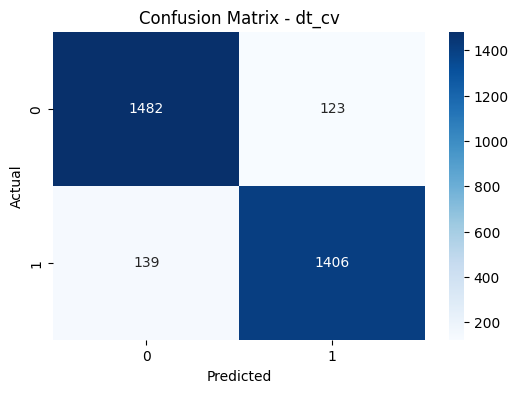

In [106]:
pred_dt_cv = dtc_cv.predict(Xv_testCV)
accuracy = accuracy_score(y_test, pred_dt_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_dt_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_dt_cv,name_model="dt_cv")

In [107]:
joblib.dump(dtc_cv, model_DTC_CV)

['../../Model/Vietnamese/CV\\Vietnamese_DTC_model_CV.joblib']

### Navie bayes

In [108]:
nb_cv = MultinomialNB()
nb_cv.fit(Xv_trainCV,y_train)

MultinomialNB()

0.9574603174603175
-------------------

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1605
           1       0.96      0.96      0.96      1545

    accuracy                           0.96      3150
   macro avg       0.96      0.96      0.96      3150
weighted avg       0.96      0.96      0.96      3150

-------------------



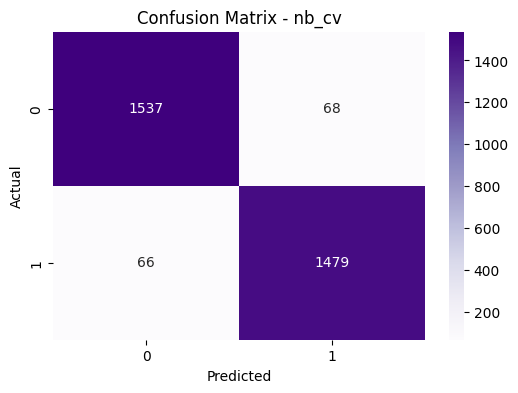

In [109]:
pred_nb_cv = nb_cv.predict(Xv_testCV)

accuracy = accuracy_score(y_test, pred_nb_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_nb_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_nb_cv,name_model="nb_cv")

In [110]:
joblib.dump(nb_cv, model_NB_CV)

['../../Model/Vietnamese/CV\\Vietnamese_NB_model_CV.joblib']

### RandomForest

In [111]:
rfc_cv = RandomForestClassifier()
rfc_cv.fit(Xv_trainCV,y_train)

RandomForestClassifier()

0.9777777777777777
-------------------

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1605
           1       0.98      0.98      0.98      1545

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



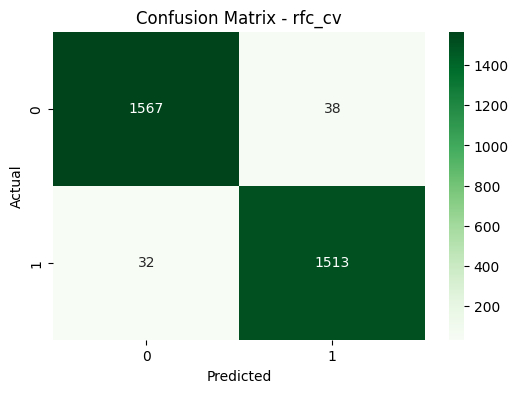

In [112]:
pred_rfc_cv = rfc_cv.predict(Xv_testCV)

accuracy = accuracy_score(y_test, pred_rfc_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_cv,name_model="rfc_cv")

In [113]:
joblib.dump(rfc_cv, model_RFC_CV)

['../../Model/Vietnamese/CV\\Vietnamese_RFC_model_CV.joblib']

### SVM

In [114]:
svm_cv = LinearSVC(random_state=42)
svm_cv.fit(Xv_trainCV, y_train)

LinearSVC(random_state=42)

0.9746031746031746
-------------------

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1605
           1       0.97      0.98      0.97      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



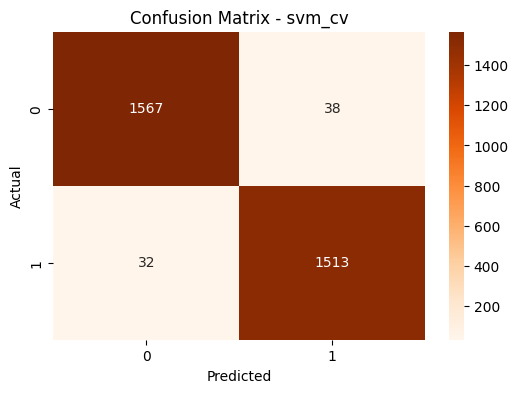

In [115]:
pred_svm_cv = svm_cv.predict(Xv_testCV)

accuracy = accuracy_score(y_test, pred_svm_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_svm_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_cv,name_model="svm_cv")

In [116]:
joblib.dump(svm_cv, model_SVM_CV)

['../../Model/Vietnamese/CV\\Vietnamese_SVM_model_CV.joblib']

### LogisticRegression

In [117]:
lr_cv = LogisticRegression()
lr_cv.fit(Xv_trainCV, y_train)
pred_lr_cv = lr_cv.predict(Xv_testCV)

0.9784126984126984
-------------------

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1605
           1       0.98      0.98      0.98      1545

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



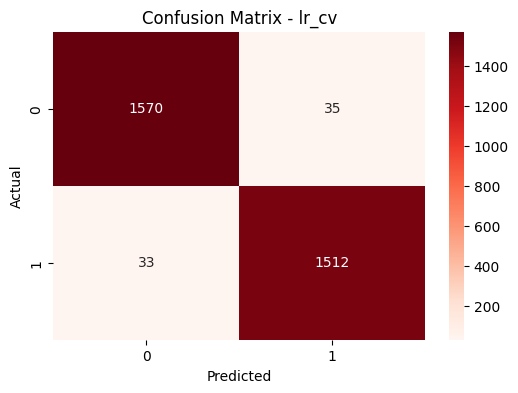

In [118]:
accuracy = accuracy_score(y_test, pred_lr_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_lr_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_lr_cv,name_model="lr_cv")

In [119]:
joblib.dump(lr_cv, model_LR_CV)

['../../Model/Vietnamese/CV\\Vietnamese_LR_model_CV.joblib']

### GradientBoostingClassifier

In [120]:
gbc_cv = GradientBoostingClassifier(random_state=0)
gbc_cv.fit(Xv_trainCV, y_train)
pred_gbc_cv = gbc_cv.predict(Xv_testCV)

0.9593650793650793
-------------------

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1605
           1       0.95      0.96      0.96      1545

    accuracy                           0.96      3150
   macro avg       0.96      0.96      0.96      3150
weighted avg       0.96      0.96      0.96      3150

-------------------



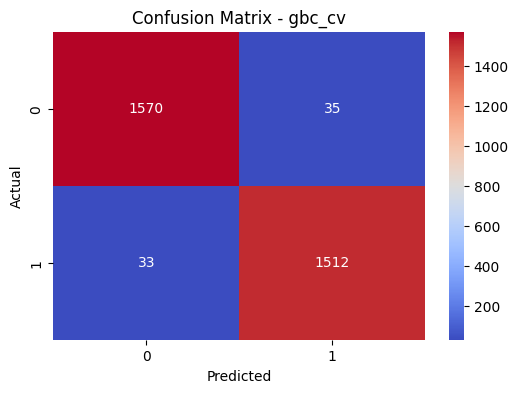

In [121]:
accuracy = accuracy_score(y_test, pred_gbc_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_gbc_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_lr_cv,name_model="gbc_cv")

In [122]:
joblib.dump(gbc_cv, model_GBC_CV)

['../../Model/Vietnamese/CV\\Vietnamese_GBC_model_CV.joblib']

## TfidfVectorizer

In [123]:
model_vector_TF = os.path.join("../../Model/Vietnamese/TF", "Vietnamese_vectorizer_TF.joblib")
model_DTC_TF = os.path.join("../../Model/Vietnamese/TF", "Vietnamese_DTC_model_TF.joblib")
model_NB_TF = os.path.join("../../Model/Vietnamese/TF", "Vietnamese_NB_model_TF.joblib")
model_RFC_TF = os.path.join("../../Model/Vietnamese/TF", "Vietnamese_RFC_model_TF.joblib")
model_SVM_TF = os.path.join("../../Model/Vietnamese/TF", "Vietnamese_SVM_model_TF.joblib")
model_LR_TF = os.path.join("../../Model/Vietnamese/TF", "Vietnamese_LR_model_TF.joblib")
model_GBC_TF = os.path.join("../../Model/Vietnamese/TF", "Vietnamese_GBC_model_TF.joblib")

In [124]:
vectorizerTF = TfidfVectorizer(
                            stop_words=stopwords,
                            tokenizer=tokenize,
                            min_df=0.001,          
                            max_df=0.5,            
                            max_features=12000, 
                            use_idf=True, 
                            ngram_range=(1,3)
                            )

In [125]:
Xv_trainTF = vectorizerTF.fit_transform(X_train)
Xv_testTF = vectorizerTF.transform(X_test)

In [126]:
joblib.dump(vectorizerTF, model_vector_TF)

['../../Model/Vietnamese/TF\\Vietnamese_vectorizer_TF.joblib']

### DecisionTreeClassifier

In [127]:
dtc_tf = DecisionTreeClassifier()
dtc_tf.fit(Xv_trainTF,y_train)

DecisionTreeClassifier()

In [128]:
pred_dtc_tf = dtc_tf.predict(Xv_testTF)

0.9165079365079365
-------------------

              precision    recall  f1-score   support

           0       0.92      0.91      0.92      1605
           1       0.91      0.92      0.92      1545

    accuracy                           0.92      3150
   macro avg       0.92      0.92      0.92      3150
weighted avg       0.92      0.92      0.92      3150

-------------------



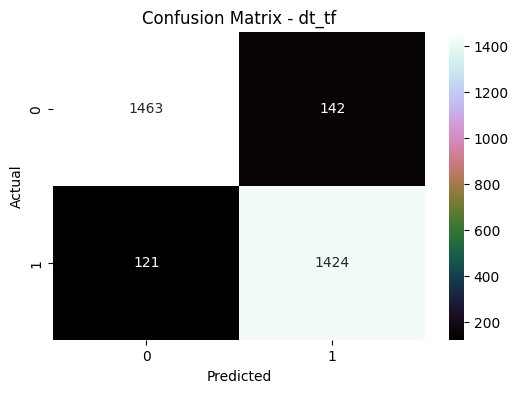

In [129]:
accuracy = accuracy_score(y_test, pred_dtc_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_dtc_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_dtc_tf,name_model="dt_tf")

In [130]:
joblib.dump(dtc_tf, model_DTC_TF)

['../../Model/Vietnamese/TF\\Vietnamese_DTC_model_TF.joblib']

### Navie bayes

In [131]:
nb_tf = MultinomialNB()
nb_tf.fit(Xv_trainTF,y_train)

MultinomialNB()

In [132]:
pred_nb_tf = nb_tf.predict(Xv_testTF)

0.9488888888888889
-------------------

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1605
           1       0.94      0.96      0.95      1545

    accuracy                           0.95      3150
   macro avg       0.95      0.95      0.95      3150
weighted avg       0.95      0.95      0.95      3150

-------------------



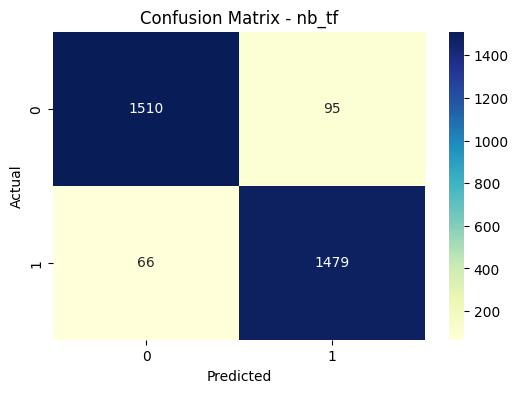

In [133]:
accuracy = accuracy_score(y_test, pred_nb_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_nb_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_nb_tf,name_model="nb_tf")

In [134]:
joblib.dump(nb_tf, model_NB_TF)

['../../Model/Vietnamese/TF\\Vietnamese_NB_model_TF.joblib']

### RandomForest

In [135]:
rfc_tf = RandomForestClassifier()
rfc_tf.fit(Xv_trainTF,y_train)

RandomForestClassifier()

In [136]:
pred_rfc_tf = rfc_tf.predict(Xv_testTF)

0.9752380952380952
-------------------

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1605
           1       0.97      0.98      0.97      1545

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



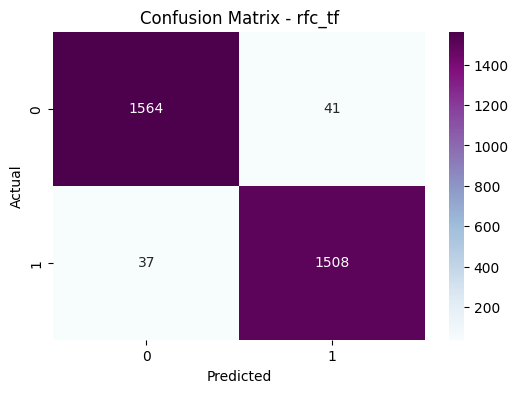

In [137]:
accuracy = accuracy_score(y_test, pred_rfc_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_tf,name_model="rfc_tf")

In [138]:
joblib.dump(rfc_tf, model_RFC_TF)

['../../Model/Vietnamese/TF\\Vietnamese_RFC_model_TF.joblib']

### SVM

In [139]:
svm_tf = LinearSVC(random_state=42)
svm_tf.fit(Xv_trainTF, y_train)

LinearSVC(random_state=42)

In [140]:
pred_svm_tf = svm_tf.predict(Xv_testTF)

0.9822222222222222
-------------------

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1605
           1       0.99      0.98      0.98      1545

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



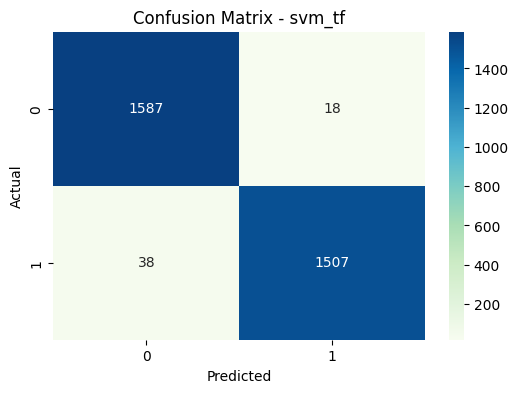

In [141]:
accuracy = accuracy_score(y_test, pred_svm_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_svm_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_svm_tf,name_model="svm_tf")

In [142]:
joblib.dump(svm_tf, model_SVM_TF)

['../../Model/Vietnamese/TF\\Vietnamese_SVM_model_TF.joblib']

### LogisticRegression

In [143]:
lr_tf = LogisticRegression()
lr_tf.fit(Xv_trainTF, y_train)
pred_lr_tf = lr_tf.predict(Xv_testTF)

0.9739682539682539
-------------------

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1605
           1       0.98      0.97      0.97      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



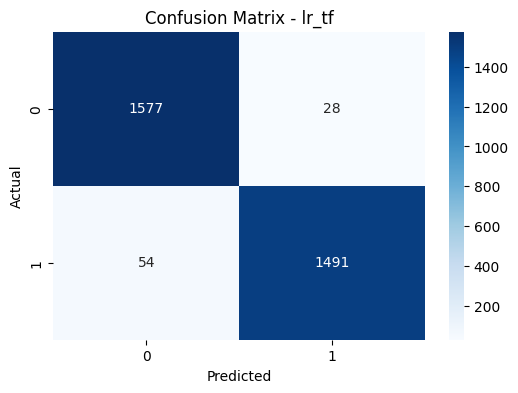

In [144]:
accuracy = accuracy_score(y_test, pred_lr_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_lr_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_lr_tf,name_model="lr_tf")

In [145]:
joblib.dump(lr_tf, model_LR_TF)

['../../Model/Vietnamese/TF\\Vietnamese_LR_model_TF.joblib']

### GradientBoostingClassifier

In [146]:
gbc_tf = GradientBoostingClassifier(random_state=0)
gbc_tf.fit(Xv_trainTF, y_train)
pred_gbc_tf = gbc_tf.predict(Xv_testTF)


0.960952380952381
-------------------

              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1605
           1       0.96      0.97      0.96      1545

    accuracy                           0.96      3150
   macro avg       0.96      0.96      0.96      3150
weighted avg       0.96      0.96      0.96      3150

-------------------



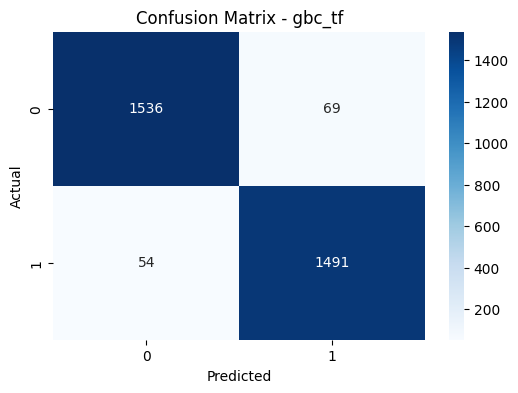

In [147]:
accuracy = accuracy_score(y_test, pred_gbc_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_gbc_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_gbc_tf,name_model="gbc_tf")

In [148]:
joblib.dump(gbc_tf, model_GBC_TF)

['../../Model/Vietnamese/TF\\Vietnamese_GBC_model_TF.joblib']

## Word2Vec

In [149]:
model_vector_W2V = os.path.join("../../Model/Vietnamese/W2V", "Vietnamese_vectorizer_W2V.joblib")
model_DTC_W2V = os.path.join("../../Model/Vietnamese/W2V", "Vietnamese_DTC_model_W2V.joblib")
model_NB_W2V = os.path.join("../../Model/Vietnamese/W2V", "Vietnamese_NB_model_W2V.joblib")
model_RFC_W2V = os.path.join("../../Model/Vietnamese/W2V", "Vietnamese_RFC_model_W2V.joblib")
model_SVM_W2V = os.path.join("../../Model/Vietnamese/W2V", "Vietnamese_SVM_model_W2V.joblib")
model_LR_W2V = os.path.join("../../Model/Vietnamese/W2V", "Vietnamese_LR_model_W2V.joblib")
model_GBC_W2V = os.path.join("../../Model/Vietnamese/W2V", "Vietnamese_GBC_model_W2V.joblib")

In [150]:
def makeWords(sentences):
    wordList = []
    for sentence in sentences:
        words = sentence.split(' ')
        wordList.append(words)
    return wordList

words_train_W2V = makeWords(X_train)
words_test_W2V = makeWords(X_test)

In [151]:
# Train the Word2Vec model on the tokenized training sentences
vectorizerW2V = Word2Vec(
    sentences=words_train_W2V,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=0,
    epochs=20
)

In [152]:
def sentence_vector(sentence, model):
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

In [153]:
Xv_trainW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_train_W2V])
Xv_testW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_test_W2V])

In [154]:
joblib.dump(vectorizerW2V,model_vector_W2V)

['../../Model/Vietnamese/W2V\\Vietnamese_vectorizer_W2V.joblib']

### Decision Tree

In [155]:
dtc_w2v = DecisionTreeClassifier()
dtc_w2v.fit(Xv_trainW2V, y_train)

DecisionTreeClassifier()

In [156]:
pred_dtc_w2v = dtc_w2v.predict(Xv_testW2V)

0.9180952380952381
-------------------

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1605
           1       0.92      0.91      0.92      1545

    accuracy                           0.92      3150
   macro avg       0.92      0.92      0.92      3150
weighted avg       0.92      0.92      0.92      3150

-------------------



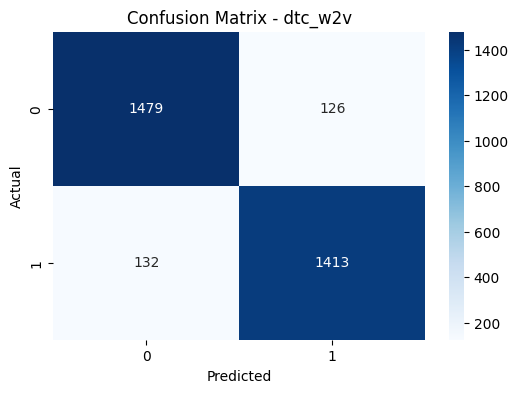

In [157]:
accuracy = accuracy_score(y_test, pred_dtc_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_dtc_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_dtc_w2v,name_model="dtc_w2v")

In [158]:
joblib.dump(dtc_w2v, model_DTC_W2V)

['../../Model/Vietnamese/W2V\\Vietnamese_DTC_model_W2V.joblib']

### Navie bayes

In [159]:
nb_w2v = GaussianNB()
nb_w2v.fit(Xv_trainW2V,y_train)

GaussianNB()

In [160]:
pred_np_w2v = nb_w2v.predict(Xv_testW2V)

0.8977777777777778
-------------------

              precision    recall  f1-score   support

           0       0.91      0.88      0.90      1605
           1       0.88      0.91      0.90      1545

    accuracy                           0.90      3150
   macro avg       0.90      0.90      0.90      3150
weighted avg       0.90      0.90      0.90      3150

-------------------



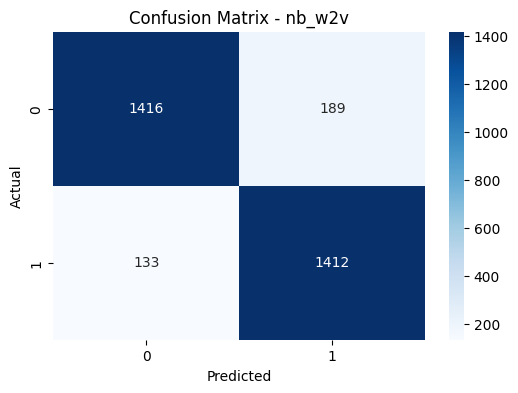

In [161]:
accuracy = accuracy_score(y_test, pred_np_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_np_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_np_w2v,name_model="nb_w2v")

In [162]:
joblib.dump(nb_w2v, model_NB_W2V)

['../../Model/Vietnamese/W2V\\Vietnamese_NB_model_W2V.joblib']

### RandomForest

In [163]:
rfc_w2v = RandomForestClassifier()
rfc_w2v.fit(Xv_trainW2V, y_train)

RandomForestClassifier()

In [164]:
pred_rfc_w2v = rfc_w2v.predict(Xv_testW2V)

0.9628571428571429
-------------------

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1605
           1       0.97      0.95      0.96      1545

    accuracy                           0.96      3150
   macro avg       0.96      0.96      0.96      3150
weighted avg       0.96      0.96      0.96      3150

-------------------



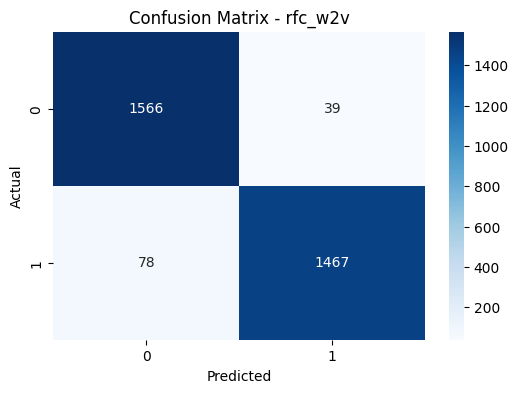

In [165]:
accuracy = accuracy_score(y_test, pred_rfc_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_w2v,name_model="rfc_w2v")

In [166]:
joblib.dump(rfc_w2v, model_RFC_W2V)

['../../Model/Vietnamese/W2V\\Vietnamese_RFC_model_W2V.joblib']

### SVM

In [167]:
svm_w2v = LinearSVC(random_state=42)
svm_w2v.fit(Xv_trainW2V, y_train)

LinearSVC(random_state=42)

In [168]:
pred_svm_w2v = svm_w2v.predict(Xv_testW2V)

0.9685714285714285
-------------------

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1605
           1       0.97      0.97      0.97      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



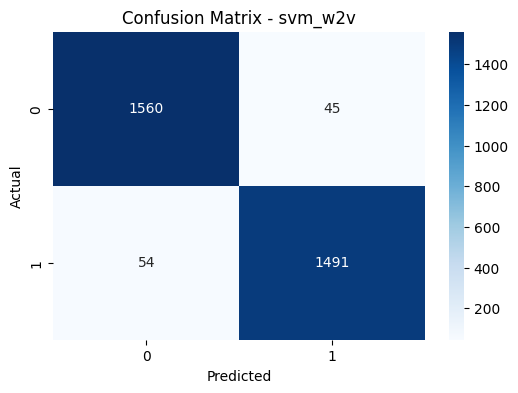

In [169]:
accuracy = accuracy_score(y_test, pred_svm_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_svm_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_svm_w2v,name_model="svm_w2v")

In [170]:
joblib.dump(svm_w2v, model_SVM_W2V)

['../../Model/Vietnamese/W2V\\Vietnamese_SVM_model_W2V.joblib']

### LogisticRegression

In [171]:
lr_w2v = LogisticRegression()
lr_w2v.fit(Xv_trainW2V, y_train)
pred_lr_w2v = lr_w2v.predict(Xv_testW2V)

0.9688888888888889
-------------------

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1605
           1       0.97      0.97      0.97      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



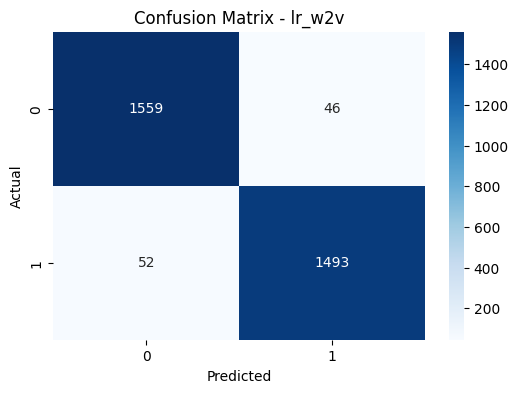

In [172]:
accuracy = accuracy_score(y_test, pred_lr_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_lr_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_lr_w2v,name_model="lr_w2v")

In [173]:
joblib.dump(lr_w2v, model_LR_W2V)

['../../Model/Vietnamese/W2V\\Vietnamese_LR_model_W2V.joblib']

### GradientBoostingClassifier

In [174]:
gbc_w2v = GradientBoostingClassifier(random_state=0)
gbc_w2v.fit(Xv_trainW2V, y_train)
pred_gbc_w2v = gbc_w2v.predict(Xv_testW2V)

0.9631746031746031
-------------------

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1605
           1       0.97      0.96      0.96      1545

    accuracy                           0.96      3150
   macro avg       0.96      0.96      0.96      3150
weighted avg       0.96      0.96      0.96      3150

-------------------



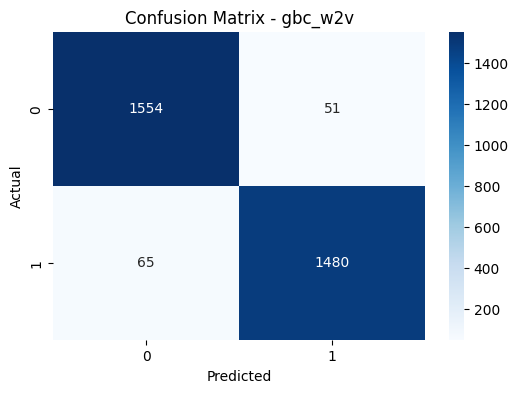

In [175]:
accuracy = accuracy_score(y_test, pred_gbc_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_gbc_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_gbc_w2v,name_model="gbc_w2v")

In [176]:
joblib.dump(gbc_w2v, model_GBC_W2V)

['../../Model/Vietnamese/W2V\\Vietnamese_GBC_model_W2V.joblib']

## Doc2Vec

In [177]:
model_vector_D2V = os.path.join("../../Model/Vietnamese/D2V", "Vietnamese_vectorizer_D2V.joblib")
model_DTC_D2V = os.path.join("../../Model/Vietnamese/D2V", "Vietnamese_DTC_model_D2V.joblib")
model_NB_D2V = os.path.join("../../Model/Vietnamese/D2V", "Vietnamese_NB_model_D2V.joblib")
model_RFC_D2V = os.path.join("../../Model/Vietnamese/D2V", "Vietnamese_RFC_model_D2V.joblib")
model_SVM_D2V = os.path.join("../../Model/Vietnamese/D2V", "Vietnamese_SVM_model_D2V.joblib")
model_LR_D2V = os.path.join("../../Model/VietNamese/D2V", "VietNamese_LR_model_D2V.joblib")
model_GBC_D2V = os.path.join("../../Model/VietNamese/D2V", "VietNamese_GBC_model_D2V.joblib")

In [178]:
def preprocess(doc):
    tokens = tokenize(doc)
    return [word for word in tokens if word not in stopwords]

In [179]:
documents = [TaggedDocument(preprocess(doc), [i]) for i, doc in enumerate(X_train)]

In [180]:
vectorizerD2V = Doc2Vec(
    documents=documents,  # Truyền documents trực tiếp
    vector_size=100,      # Kích thước vector
    window=5,             # Kích thước cửa sổ ngữ cảnh
    min_count=1,          # Bỏ qua từ xuất hiện ít hơn min_count
    workers=4,            # Số luồng để huấn luyện
    epochs=20             # Số lần lặp để huấn luyện
)

In [181]:
Xv_trainD2V = [vectorizerD2V.infer_vector(doc.split()) for doc in X_train]
Xv_testD2V = [vectorizerD2V.infer_vector(doc.split()) for doc in X_test]

In [182]:
joblib.dump(vectorizerD2V, model_vector_D2V)

['../../Model/Vietnamese/D2V\\Vietnamese_vectorizer_D2V.joblib']

### DecisionTreeClassifier

In [183]:
dtc_d2v = DecisionTreeClassifier()
dtc_d2v.fit(Xv_trainD2V, y_train)

DecisionTreeClassifier()

In [184]:
pred_dtc_d2v = dtc_d2v.predict(Xv_testD2V)

0.8022222222222222
-------------------

              precision    recall  f1-score   support

           0       0.83      0.76      0.80      1605
           1       0.77      0.84      0.81      1545

    accuracy                           0.80      3150
   macro avg       0.80      0.80      0.80      3150
weighted avg       0.80      0.80      0.80      3150

-------------------



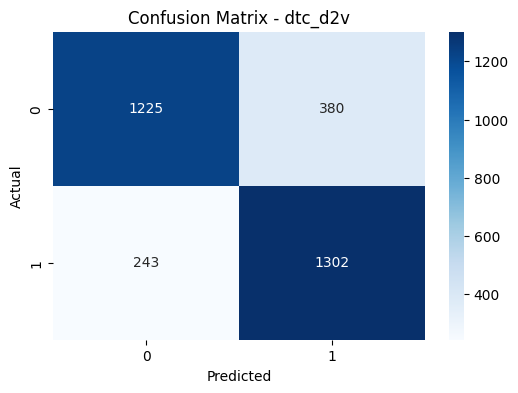

In [185]:
accuracy = accuracy_score(y_test, pred_dtc_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_dtc_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_dtc_d2v,name_model="dtc_d2v",save=True)

In [186]:
joblib.dump(dtc_d2v, model_DTC_D2V)

['../../Model/Vietnamese/D2V\\Vietnamese_DTC_model_D2V.joblib']

### Navie bayes

In [187]:
nb_d2v = GaussianNB()
nb_d2v.fit(Xv_trainD2V,y_train)

GaussianNB()

In [188]:
pred_nb_d2v = nb_d2v.predict(Xv_testD2V)

0.7355555555555555
-------------------

              precision    recall  f1-score   support

           0       0.73      0.76      0.75      1605
           1       0.74      0.71      0.73      1545

    accuracy                           0.74      3150
   macro avg       0.74      0.74      0.74      3150
weighted avg       0.74      0.74      0.74      3150

-------------------



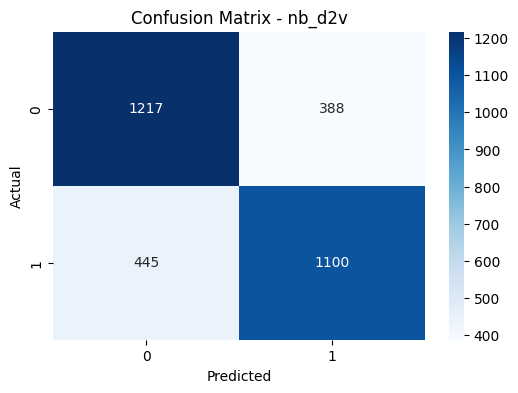

In [189]:
accuracy = accuracy_score(y_test, pred_nb_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_nb_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_nb_d2v,name_model="nb_d2v",save=True)

In [190]:
joblib.dump(nb_d2v, model_NB_D2V)

['../../Model/Vietnamese/D2V\\Vietnamese_NB_model_D2V.joblib']

### RandomForest

In [191]:
rfc_d2v = RandomForestClassifier()
rfc_d2v.fit(Xv_trainD2V, y_train)

RandomForestClassifier()

In [192]:
pred_rfc_d2v = rfc_d2v.predict(Xv_testD2V)

0.9393650793650794
-------------------

              precision    recall  f1-score   support

           0       0.96      0.92      0.94      1605
           1       0.92      0.96      0.94      1545

    accuracy                           0.94      3150
   macro avg       0.94      0.94      0.94      3150
weighted avg       0.94      0.94      0.94      3150

-------------------



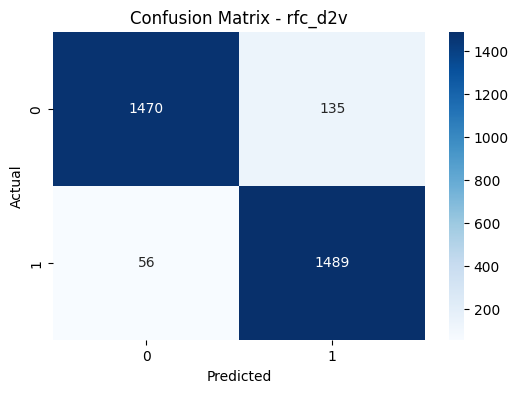

In [193]:
accuracy = accuracy_score(y_test, pred_rfc_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_d2v,name_model="rfc_d2v",save=True)

In [194]:
joblib.dump(rfc_d2v, model_RFC_D2V)

['../../Model/Vietnamese/D2V\\Vietnamese_RFC_model_D2V.joblib']

### SVM

In [195]:
svm_d2v = LinearSVC(random_state=42)
svm_d2v.fit(Xv_trainD2V, y_train)

LinearSVC(random_state=42)

In [196]:
pred_svm_d2v = svm_d2v.predict(Xv_testD2V)

0.9498412698412698
-------------------

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1605
           1       0.94      0.96      0.95      1545

    accuracy                           0.95      3150
   macro avg       0.95      0.95      0.95      3150
weighted avg       0.95      0.95      0.95      3150

-------------------



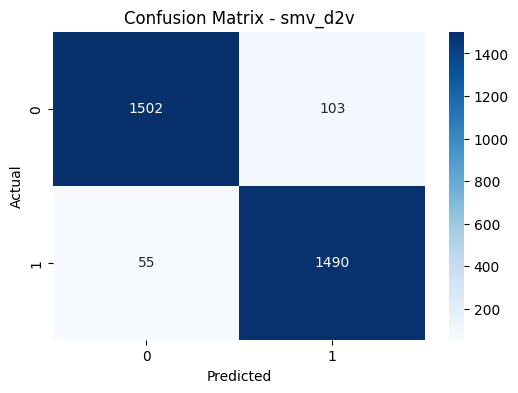

In [197]:
accuracy = accuracy_score(y_test, pred_svm_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_svm_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_svm_d2v,name_model="smv_d2v",save=True)

In [198]:
joblib.dump(svm_d2v, model_SVM_D2V)

['../../Model/Vietnamese/D2V\\Vietnamese_SVM_model_D2V.joblib']

### LogisticRegression

In [199]:
lr_d2v = LogisticRegression()
lr_d2v.fit(Xv_trainD2V, y_train)
pred_lr_d2v = lr_d2v.predict(Xv_testD2V)

0.9507936507936507
-------------------

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1605
           1       0.94      0.96      0.95      1545

    accuracy                           0.95      3150
   macro avg       0.95      0.95      0.95      3150
weighted avg       0.95      0.95      0.95      3150

-------------------



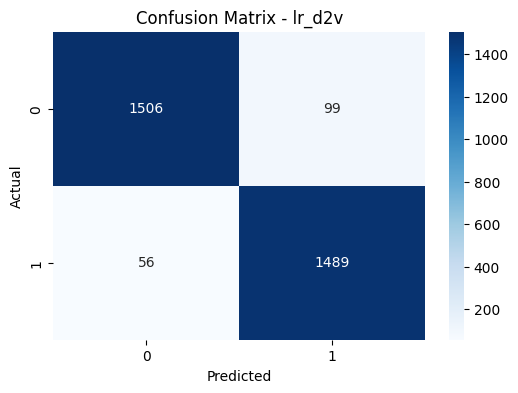

In [200]:
accuracy = accuracy_score(y_test, pred_lr_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_lr_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_lr_d2v,name_model="lr_d2v")

In [201]:
joblib.dump(lr_d2v, model_LR_D2V)

['../../Model/VietNamese/D2V\\VietNamese_LR_model_D2V.joblib']

### GradientBoostingClassifier

In [202]:
gbc_d2v = GradientBoostingClassifier(random_state=0)
gbc_d2v.fit(Xv_trainD2V, y_train)
pred_gbc_d2v = gbc_d2v.predict(Xv_testD2V)

0.9333333333333333
-------------------

              precision    recall  f1-score   support

           0       0.96      0.91      0.93      1605
           1       0.91      0.96      0.93      1545

    accuracy                           0.93      3150
   macro avg       0.93      0.93      0.93      3150
weighted avg       0.93      0.93      0.93      3150

-------------------



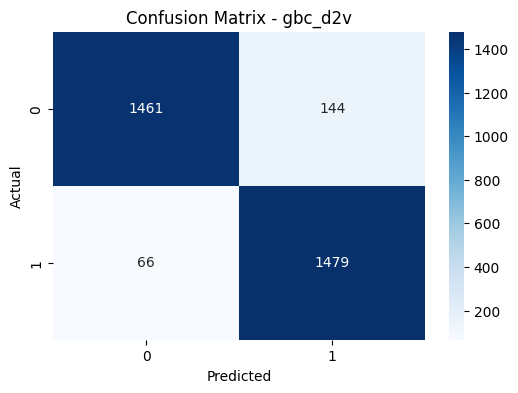

In [203]:
accuracy = accuracy_score(y_test, pred_gbc_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_gbc_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_gbc_d2v,name_model="gbc_d2v")

In [204]:
joblib.dump(gbc_d2v, model_GBC_D2V)

['../../Model/VietNamese/D2V\\VietNamese_GBC_model_D2V.joblib']